<a href="https://colab.research.google.com/github/uzair011/random-codes/blob/main/Quant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Display settings for better look
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)


In [19]:
# Section 1: load file
CSV_PATH = "wintermute_transfers_search_default_2025-04-08.csv"
df = pd.read_csv(CSV_PATH)
df.head()


,timestamp,from_address,from_entity,to_address,to_entity,token,value,usd,tx_hash,chain,block_number
0,2025-04-08 12:49:57+00:00,0xB1026b8e7276e7AC75410F1fcbbe21796e8f7526,Camelot,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,USDC,438.108563,438.108563,0x98058c529466064c355bdfea3cfebe399344678f20bb...,arbitrum_one,324218955.0
1,2025-04-08 12:49:54+00:00,0xcDa53B1F66614552F834cEeF361A8D12a0B8DaD8,Uniswap,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,ARB,3837.138536,1062.879700,0x405b146ac6a52b93e5a77760a4b49a87015b5c5e0659...,arbitrum_one,324218945.0
2,2025-04-08 12:49:51+00:00,0xb2cc224c1c9feE385f8ad6a55b4d94E92359DC59,Aerodrome Finance,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,WETH,7.345922,11533.612401,0x7f370fc61bed7241d846c4907a4e616e69ce60ff0192...,base,28663622.0
3,2025-04-08 12:49:51+00:00,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,0x72AB388E2E2F6FaceF59E3C3FA2C4E29011c2D38,PancakeSwap,USDC,2143.712587,2143.712587,0x88b4fb948e95cc2b9a22c48efe3d6a6788209302e72f...,base,28663622.0
4,2025-04-08 12:49:50+00:00,0x641C00A822e8b671738d32a431a4Fb6074E5c79d,Uniswap,0x51C72848c68a965f66FA7a88855F9f7784502a7F,Wintermute,WETH,0.470011,737.550466,0x39fc603c882c2f5af51b7f8cfc8eb58753f5e42eff94...,arbitrum_one,324218918.0


In [20]:
# Section 2: cleaning and normalization

# 1) timestamps -> datetime (coerce bad values)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# 2) normalize entity strings (upper-case, fill NAs) to avoid case mismatches
df['from_entity'] = df['from_entity'].fillna('').astype(str).str.strip().str.upper()
df['to_entity']   = df['to_entity'].fillna('').astype(str).str.strip().str.upper()

# 3) token symbol normalization
df['token_symbol'] = df['token'].fillna(df['token'].astype(str)).astype(str).str.upper()

# 4) numeric conversions for sums and averages
df['value'] = pd.to_numeric(df['value'], errors='coerce').fillna(0)
df['usd']   = pd.to_numeric(df['usd'], errors='coerce').fillna(0)

# 5) to make sure no more cleaning problems exist...
print("rows:", len(df))
print("null timestamps:", df['timestamp'].isna().sum())
print("unique counterparties (from/to):", len(pd.concat([df['from_entity'], df['to_entity']]).unique()))

df.head()


rows: 242819
null timestamps: 0
unique counterparties (from/to): 67


,timestamp,from_address,from_entity,to_address,to_entity,token,value,usd,tx_hash,chain,block_number,token_symbol
0,2025-04-08 12:49:57+00:00,0xB1026b8e7276e7AC75410F1fcbbe21796e8f7526,CAMELOT,0x51C72848c68a965f66FA7a88855F9f7784502a7F,WINTERMUTE,USDC,438.108563,438.108563,0x98058c529466064c355bdfea3cfebe399344678f20bb...,arbitrum_one,324218955.0,USDC
1,2025-04-08 12:49:54+00:00,0xcDa53B1F66614552F834cEeF361A8D12a0B8DaD8,UNISWAP,0x51C72848c68a965f66FA7a88855F9f7784502a7F,WINTERMUTE,ARB,3837.138536,1062.879700,0x405b146ac6a52b93e5a77760a4b49a87015b5c5e0659...,arbitrum_one,324218945.0,ARB
2,2025-04-08 12:49:51+00:00,0xb2cc224c1c9feE385f8ad6a55b4d94E92359DC59,AERODROME FINANCE,0x51C72848c68a965f66FA7a88855F9f7784502a7F,WINTERMUTE,WETH,7.345922,11533.612401,0x7f370fc61bed7241d846c4907a4e616e69ce60ff0192...,base,28663622.0,WETH
3,2025-04-08 12:49:51+00:00,0x51C72848c68a965f66FA7a88855F9f7784502a7F,WINTERMUTE,0x72AB388E2E2F6FaceF59E3C3FA2C4E29011c2D38,PANCAKESWAP,USDC,2143.712587,2143.712587,0x88b4fb948e95cc2b9a22c48efe3d6a6788209302e72f...,base,28663622.0,USDC
4,2025-04-08 12:49:50+00:00,0x641C00A822e8b671738d32a431a4Fb6074E5c79d,UNISWAP,0x51C72848c68a965f66FA7a88855F9f7784502a7F,WINTERMUTE,WETH,0.470011,737.550466,0x39fc603c882c2f5af51b7f8cfc8eb58753f5e42eff94...,arbitrum_one,324218918.0,WETH


In [21]:
# Section 3: detect and compute 'counterparty' column

def get_counterparty(row):
    fe = row['from_entity']
    te = row['to_entity']
    # If Wintermute is on the sender side -> counterparty is receiver
    if 'WINTERMUTE' in fe:
        return te
    # If Wintermute is receiver -> counterparty is sender
    elif 'WINTERMUTE' in te:
        return fe
    # fallback: prefer non-empty to_entity, else from_entity
    else:
        return te if te.strip() != '' else fe

df['counterparty'] = df.apply(get_counterparty, axis=1)
df['counterparty'] = df['counterparty'].fillna('').str.strip().str.upper()

# quick check to confirm...
print(df[['from_entity','to_entity','counterparty']].head(10))
print("\nTop counterparties (count):")
print(df['counterparty'].value_counts().head(30))


         from_entity    to_entity       counterparty
0            CAMELOT   WINTERMUTE            CAMELOT
1            UNISWAP   WINTERMUTE            UNISWAP
2  AERODROME FINANCE   WINTERMUTE  AERODROME FINANCE
3         WINTERMUTE  PANCAKESWAP        PANCAKESWAP
4            UNISWAP   WINTERMUTE            UNISWAP
5         WINTERMUTE      UNISWAP            UNISWAP
6            CAMELOT   WINTERMUTE            CAMELOT
7        PANCAKESWAP   WINTERMUTE        PANCAKESWAP
8            UNISWAP   WINTERMUTE            UNISWAP
9        PANCAKESWAP   WINTERMUTE        PANCAKESWAP

Top counterparties (count):
counterparty
RAYDIUM                      51954
ORCA                         48589
UNISWAP                      27947
JITO                         26090
                             23772
METEORA (PREV. MERCURIAL)    21358
PANCAKESWAP                  11456
FLUID (INSTADAPP)             7924
CAMELOT                       6779
AERODROME FINANCE             5007
PHOENIX                  

In [22]:
# Section 4: classification mapping and function

# Mapping tuned to the dataset's common counterparties
# high-confidence mappings for frequent names seen the output
mapping = {
    # DEX / AMM / Aggregators / Lending / Staking ...
    'ORCA': ('DeFi', 'DEX'),
    'RAYDIUM': ('DeFi', 'DEX'),
    'UNISWAP': ('DeFi', 'DEX'),
    'PANCAKESWAP': ('DeFi', 'DEX'),
    'CAMELOT': ('DeFi', 'DEX'),
    'AERODROME FINANCE': ('DeFi', 'DEX'),
    'VELODROME FINANCE': ('DeFi', 'DEX'),
    'PHOENIX': ('DeFi', 'DEX'),
    'METEORA (PREV. MERCURIAL)': ('DeFi', 'Liquidity/AMM'),
    'CURVE.FI': ('DeFi', 'Stableswap/DEX'),
    'COW PROTOCOL': ('DeFi', 'Aggregator'),
    'PARASWAP': ('DeFi', 'Aggregator'),
    'FLUID (INSTADAPP)': ('DeFi', 'Lending/Automation'),
    'JITO': ('DeFi', 'Staking/MEV'),
    # Non-DeFi / others
    'BINANCE': ('Non-DeFi', 'CEX'),
    'METAMASK': ('Non-DeFi', 'Wallet'),
    'WINTERMUTE': ('Internal', 'Internal'),
    'RIZZOLVER (WINTERMUTE)': ('Internal', 'Internal'),
    # fallback numeric/empty label
    '42515': ('Unknown', 'Unknown')
}

# classifier -> mapping, else heuristics (heuristics to classify unseen labels)
def classify_counterparty(cp):
    if not isinstance(cp, str) or cp.strip() == '':
        return ('Unknown','Unknown')
    cp_up = cp.strip().upper()
    # exact mapping
    if cp_up in mapping:
        return mapping[cp_up]
    # heuristics based on keywords
    if any(k in cp_up for k in ['SWAP','POOL','ROUTER','AMM','DEX','FINANCE','EXCHANGE']):
        return ('DeFi','DEX')
    if any(k in cp_up for k in ['WALLET','METAMASK','LEDGER','TREZOR']):
        return ('Non-DeFi','Wallet')
    if any(k in cp_up for k in ['BINANCE','KRAKEN','COINBASE','FTX','GEMINI']):
        return ('Non-DeFi','CEX')
    if 'BRIDGE' in cp_up:
        return ('Non-DeFi','Bridge')
    # fallback
    return ('Unknown','Unknown')

# apply classification
df[['category','subcategory']] = df['counterparty'].apply(lambda x: pd.Series(classify_counterparty(x)))

# quick peek
df[['counterparty','category','subcategory']].drop_duplicates().head(50)


,counterparty,category,subcategory
0,CAMELOT,DeFi,DEX
1,UNISWAP,DeFi,DEX
2,AERODROME FINANCE,DeFi,DEX
3,PANCAKESWAP,DeFi,DEX
10,FLUID (INSTADAPP),DeFi,Lending/Automation
11,,Unknown,Unknown
12,COW PROTOCOL,DeFi,Aggregator
31,RAYDIUM,DeFi,DEX
36,ORCA,DeFi,DEX
44,METEORA (PREV. MERCURIAL),DeFi,Liquidity/AMM


In [23]:
# Section 5: filter DeFi interactions
df_defi = df[df['category'] == 'DeFi'].copy()
print("Total rows:", len(df))
print("DeFi-only rows:", len(df_defi))
# top counterparties inside DeFi
print(df_defi['counterparty'].value_counts().head(30)) # counts to confirm how many transactions are DeFi.


Total rows: 242819
DeFi-only rows: 213814
counterparty
RAYDIUM                      51954
ORCA                         48589
UNISWAP                      27947
JITO                         26090
METEORA (PREV. MERCURIAL)    21358
PANCAKESWAP                  11456
FLUID (INSTADAPP)             7924
CAMELOT                       6779
AERODROME FINANCE             5007
PHOENIX                       2994
COW PROTOCOL                  1232
VELODROME FINANCE             1002
PARASWAP                       841
CURVE.FI                       487
SUSHISWAP                      128
SHIBASWAP                       24
BACKPACK EXCHANGE                2
Name: count, dtype: int64


In [24]:
# Section 6: token-level summaries
token_stats = df_defi.groupby('token_symbol').agg(
    tx_count=('tx_hash','count'),
    usd_volume=('usd','sum'),
    raw_volume=('value','sum')
).sort_values('tx_count', ascending=False).reset_index()

# show top tokens
token_stats.head(30) # Plot top tokens by transaction count and USD volume


,token_symbol,tx_count,usd_volume,raw_volume
0,USDC,62922,1.427379e+08,1.427379e+08
1,WSOL,54396,4.514763e+07,4.129488e+05
2,SOL,26090,1.439077e+03,1.314496e+01
3,WETH,21552,1.555048e+08,9.891530e+04
4,USDT,9082,3.304365e+07,3.304365e+07
5,WBTC,6537,2.776648e+07,3.502872e+02
6,CBBTC,4561,2.539584e+07,3.200596e+02
7,FARTCOIN,4155,2.423986e+06,4.192730e+06
8,ARB,3103,1.625728e+06,5.959215e+06
9,TRUMP,2458,4.165208e+06,5.302001e+05


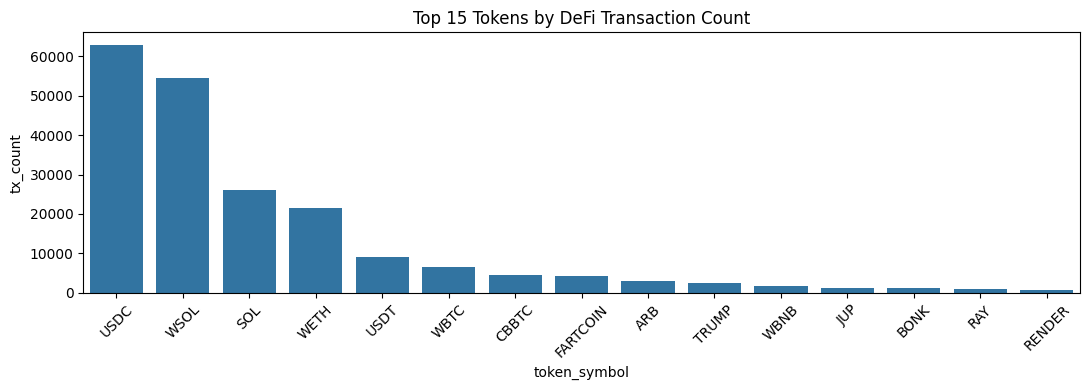

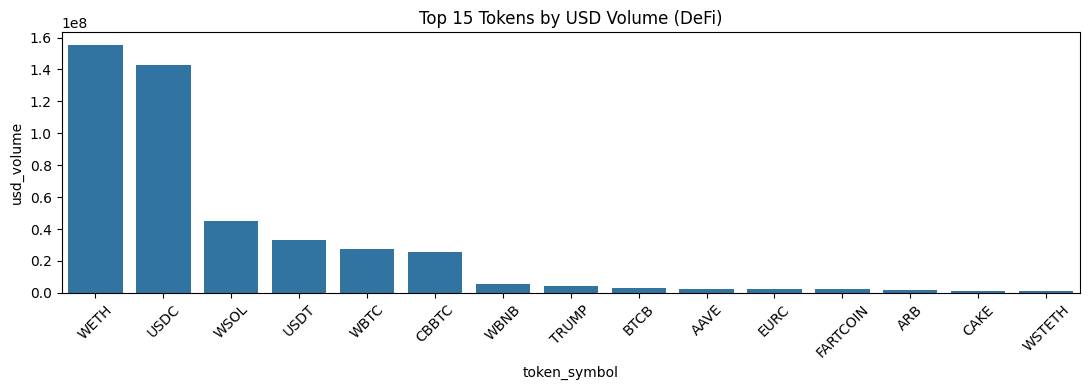

In [25]:
# top 15 by tx_count
top_n = 15
plt.figure(figsize=(11,4))
sns.barplot(x='token_symbol', y='tx_count', data=token_stats.head(top_n))
plt.title(f"Top {top_n} Tokens by DeFi Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# top 15 by USD volume
plt.figure(figsize=(11,4))
sns.barplot(x='token_symbol', y='usd_volume', data=token_stats.sort_values('usd_volume', ascending=False).head(top_n))
plt.title(f"Top {top_n} Tokens by USD Volume (DeFi)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [26]:
# Section 7: platform-level stats
platform_stats = df_defi.groupby('counterparty').agg(
    tx_count=('tx_hash','count'),
    usd_volume=('usd','sum')
).sort_values('tx_count', ascending=False).reset_index()

platform_stats.head(30)


,counterparty,tx_count,usd_volume
0,RAYDIUM,51954,1.274555e+07
1,ORCA,48589,4.888540e+07
2,UNISWAP,27947,2.126227e+08
3,JITO,26090,1.439077e+03
4,METEORA (PREV. MERCURIAL),21358,4.282775e+07
5,PANCAKESWAP,11456,2.441998e+07
6,FLUID (INSTADAPP),7924,2.475819e+07
7,CAMELOT,6779,1.956219e+06
8,AERODROME FINANCE,5007,5.992381e+07
9,PHOENIX,2994,3.431124e+06


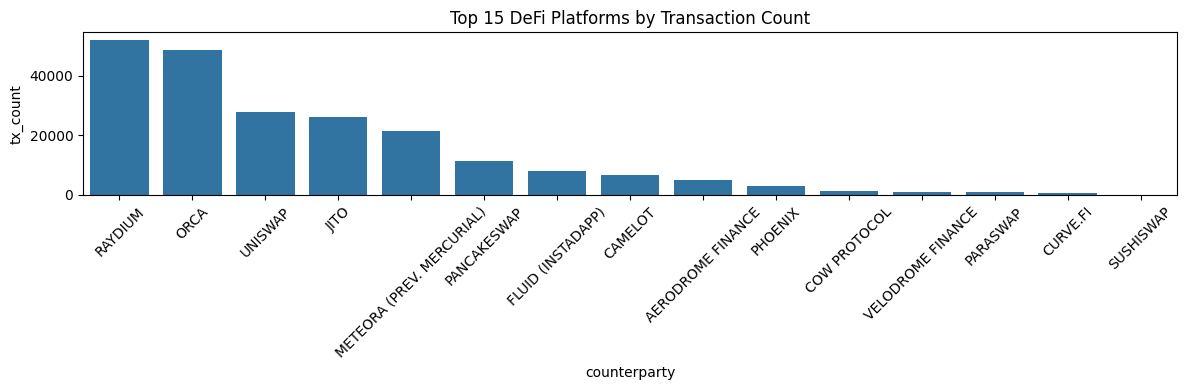

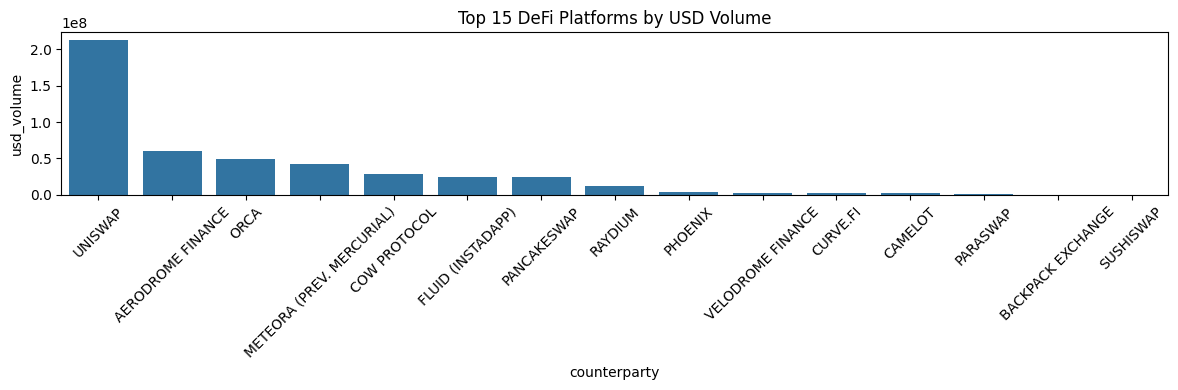

In [27]:
# Compare top-by-count vs top-by-dollar to see whether interactions are frequent or big swaps

plt.figure(figsize=(12,4))
sns.barplot(x='counterparty', y='tx_count', data=platform_stats.head(15))
plt.title("Top 15 DeFi Platforms by Transaction Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
sns.barplot(x='counterparty', y='usd_volume', data=platform_stats.sort_values('usd_volume', ascending=False).head(15))
plt.title("Top 15 DeFi Platforms by USD Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [28]:
# Section 8: chain stats
chain_stats = df_defi.groupby('chain').agg(
    tx_count=('tx_hash','count'),
    usd_volume=('usd','sum')
).sort_values('tx_count', ascending=False).reset_index()

chain_stats


,chain,tx_count,usd_volume
0,solana,150987,1.081732e+08
1,arbitrum_one,37647,3.040890e+07
2,base,10919,8.015459e+07
3,ethereum,8621,2.267743e+08
4,bsc,4196,1.750475e+07
5,optimism,1444,3.455339e+06


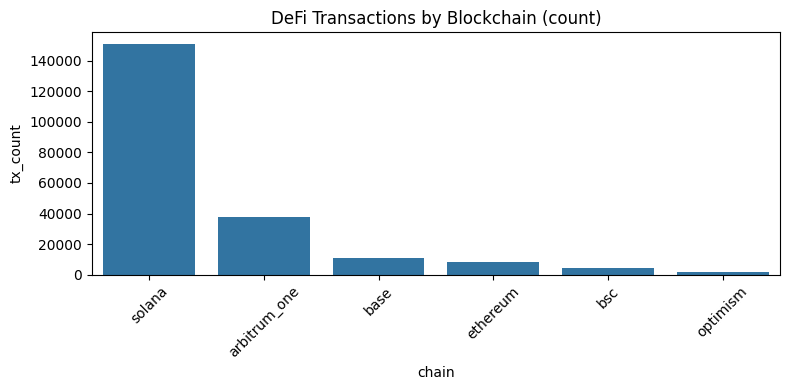

In [29]:
plt.figure(figsize=(8,4))
sns.barplot(x='chain', y='tx_count', data=chain_stats)
plt.title("DeFi Transactions by Blockchain (count)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


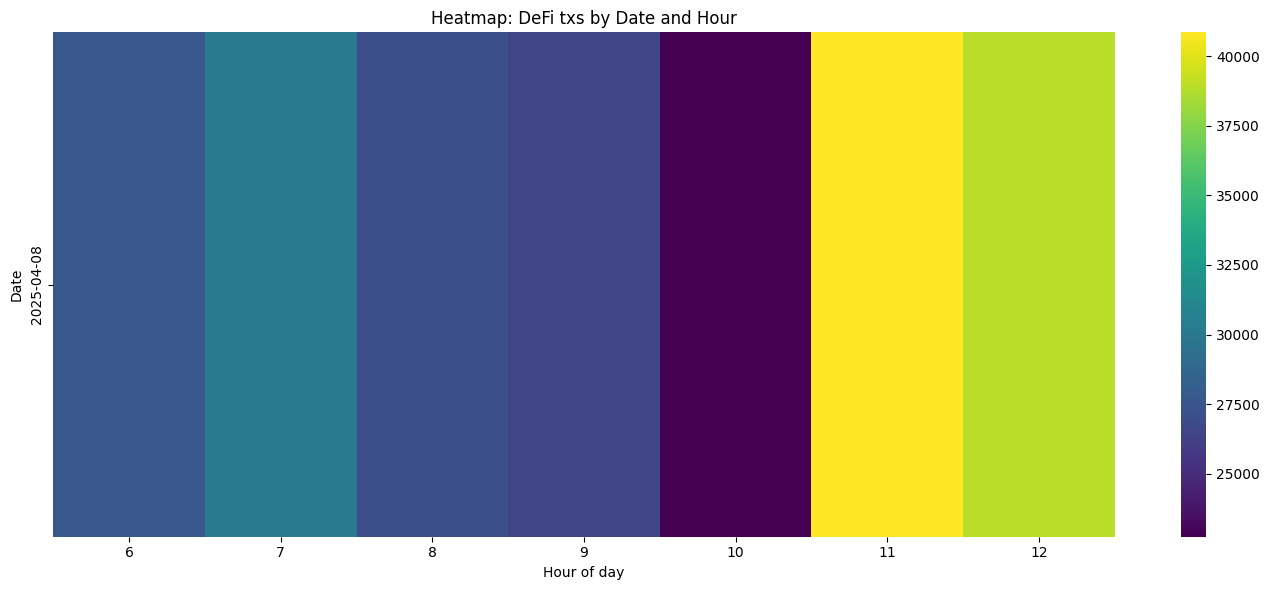

In [32]:
# Section 9: temporal features
df_defi['date'] = df_defi['timestamp'].dt.date
df_defi['hour'] = df_defi['timestamp'].dt.hour

# heatmap: rows=date, cols=hour
heat = df_defi.groupby(['date','hour']).size().unstack(fill_value=0)
plt.figure(figsize=(14,6))
sns.heatmap(heat, cmap='viridis')
plt.title("Heatmap: DeFi txs by Date and Hour")
plt.xlabel("Hour of day")
plt.ylabel("Date")
plt.tight_layout()
plt.show()


In [33]:
# Section 10: Sankey of top flows (token -> platform)
flows = df_defi.groupby(['token_symbol','counterparty']).size().reset_index(name='count')

# Keep top flows to keep visualization clear and readable
flows = flows.sort_values('count', ascending=False).head(300)

labels = list(pd.concat([flows['token_symbol'], flows['counterparty']]).unique())
label_to_idx = {lbl:i for i,lbl in enumerate(labels)}
sources = flows['token_symbol'].map(label_to_idx)
targets = flows['counterparty'].map(label_to_idx)
values = flows['count']

fig = go.Figure(data=[go.Sankey(
    node = dict(label=labels, pad=15, thickness=20),
    link = dict(source=sources, target=targets, value=values)
)])
fig.update_layout(title_text="Token → Platform flows", font_size=10)
fig.show()


In [34]:
# Section 11: export useful data/ insights...

token_stats.to_csv('tokens_summary.csv', index=False)
platform_stats.to_csv('platforms_summary.csv', index=False)
chain_stats.to_csv('chains_summary.csv', index=False)
df[['timestamp','tx_hash','counterparty','category','subcategory','token_symbol','value','usd','chain']].to_csv('df_classified_subset.csv', index=False)

print("Files exported: tokens_summary.csv, platforms_summary.csv, chains_summary.csv, df_classified_subset.csv")


Files exported: tokens_summary.csv, platforms_summary.csv, chains_summary.csv, df_classified_subset.csv
